# Using a CNN to predict images from CIFAR-10 dataset

In this lecture we are going to learn about CNN (Convolutional Neural Networks).
We will learn how to build and how to use them to make predictions.

The dataset of today's classification task is: CIFAR-10 https://www.cs.toronto.edu/~kriz/cifar.html

In [ ]:
# Run this block only if you're using the notebook on a local machine
! pip install numpy
! pip install tensorflow
! pip install matplotlib
! pip install scikit-learn
! pip install pydot
! pip install seaborn

! pip install visualkeras

In [1]:
# Libraries import
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt

### Dataset loading and some data preprocessing

In [2]:
# Loading CIFAR-10 dataset
(train_images_raw, train_labels), (test_images_raw, test_labels) = cifar10.load_data()

In [3]:
# print dataset shape
print("Shape of train_images: ", train_images_raw.shape)
# and the shape of an image
print("Image shape:", train_images_raw[0].shape)

# print the shape of the labels
print("Shape of train_labels:", train_labels.shape)
# print the labels
print("Labels: ", np.unique(train_labels))

# print the range of the values
print("Max =", np.max(train_images_raw),"  Min =", np.min(train_images_raw))


Shape of train_images:  (50000, 32, 32, 3)
Image shape: (32, 32, 3)
Shape of train_labels: (50000, 1)
Labels:  [0 1 2 3 4 5 6 7 8 9]
Max = 255   Min = 0


In [4]:
# Normalize pixel values to be between 0 and 1
train_images = train_images_raw / 255
test_images =  test_images_raw / 255

# print the range of the normalized values
print("Max =", np.max(train_images),"  Min =", np.min(train_images))

Max = 1.0   Min = 0.0


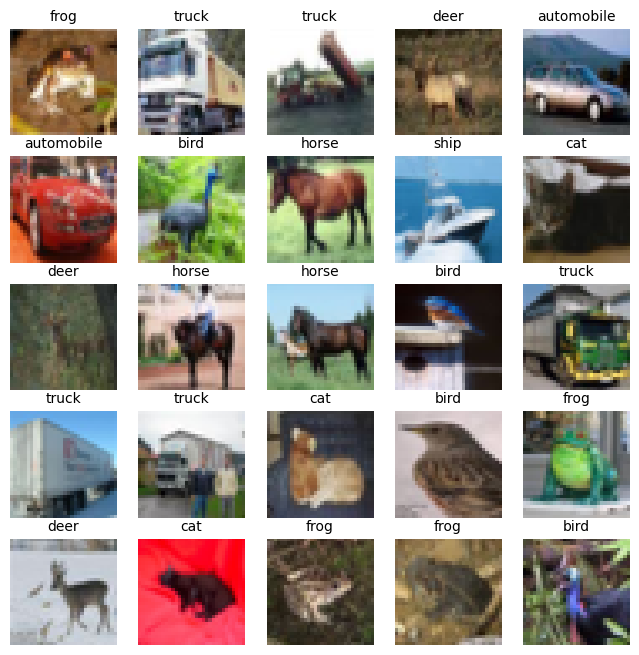

In [5]:
# Show the first 25 images in the dataset (in a grid 5x5) with the corresponding labels
# We add the dataset labels just to understand better the output. They are provided in the dataset documentation
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']             

plt.figure(figsize=(8, 8))
for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(train_images[i])
    plt.title(class_names[train_labels[i][0]], fontsize=10)
    plt.axis('off')

plt.show()

## Building the CNN

We are going to create a CNN model having these hidden layers:
1. `layer1`: conv2D having 32 filters of size 3x3, stride=1, ReLu activation
2. `layer2`: maxPool with filter size 2x2 and stride=1
3. `layer3`: conv2D having 64 filters of size 3x3, stride=1, ReLu activation
4. `layer4`: maxPool with filter size 2x2 and stride=1
5. `layer5`: conv2D having 64 filters of size 3x3, stride=1, ReLu activation,
6. `layer6`: MLP with 64 nodes

- **Keras sequential** documentation: https://keras.io/guides/sequential_model/
- **Keras documentation for Conv2D** class: https://keras.io/api/layers/convolution_layers/convolution2d/

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

# CNN model definition
model = Sequential([
    Input(shape=(32, 32, 3)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    #Dropout(0.2),
    Conv2D(64, (3, 3), activation='relu'),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')  # 10 output class
])

# Model architecture visualization
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

#### Visualize and plot the model architeture

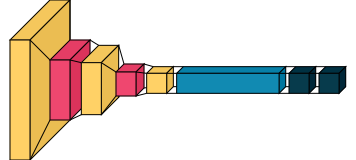

In [7]:
import visualkeras

visualkeras.layered_view(model, legend_text_spacing_offset=0).show() # display using your system viewer
visualkeras.layered_view(model, legend_text_spacing_offset=0, to_file='output.png') # write to disk

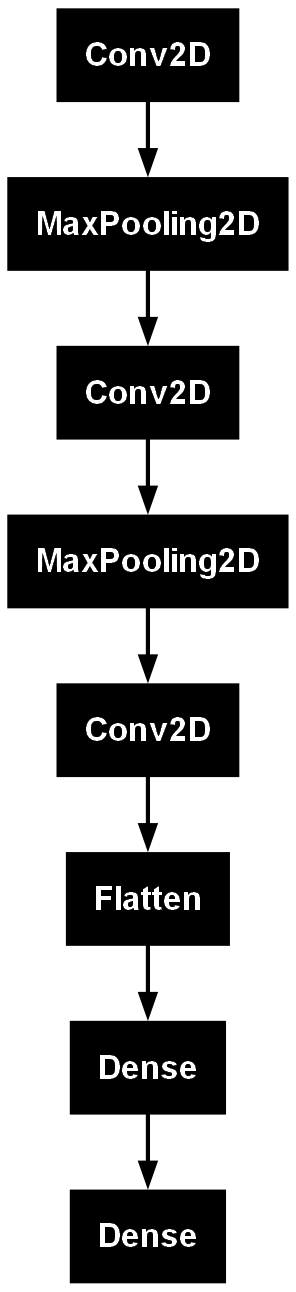

In [9]:
from keras.utils import plot_model

plot_model(model, to_file='model.png', dpi=150)

### CNN Training

In [10]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

# Model training
#history = model.fit(train_images, train_labels, epochs=15, validation_data=(test_images, test_labels))
history = model.fit(train_images, train_labels, epochs=15, validation_split=0.1)

Epoch 1/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.3309 - loss: 1.8063 - val_accuracy: 0.4890 - val_loss: 1.3976
Epoch 2/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.5325 - loss: 1.2986 - val_accuracy: 0.5938 - val_loss: 1.1479
Epoch 3/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.5988 - loss: 1.1209 - val_accuracy: 0.6396 - val_loss: 1.0360
Epoch 4/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.6432 - loss: 1.0081 - val_accuracy: 0.6646 - val_loss: 0.9761
Epoch 5/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.6729 - loss: 0.9245 - val_accuracy: 0.6824 - val_loss: 0.9064
Epoch 6/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.6966 - loss: 0.8546 - val_accuracy: 0.6628 - val_loss: 0.9673
Epoch 7/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.7194 - loss: 0.8030 - val_accuracy: 0.7020 - val_loss: 0.8681
Epoch 8/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.7342 - l

### CNN evaluation

- All the training data have been stored in a **History** object.
- Its `History.history` attribute is a record of training loss values and metrics values at successive epochs, as well as validation loss values and validation metrics values.
- If you don't remember how history is made you can run
    ```python
    type(history.history)
    ```
- Moreover, since it is a dictionary (a structure key:value) you can list the metrics stored in history (the keys) using
    ```python
    history.history.keys()
    ```

In [11]:
# Print the metrics stored in history
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

**Model evaluation**

In order to evaluate our model we want to:
- plot accuracy curve on training and validation sets
- test the model on the test set

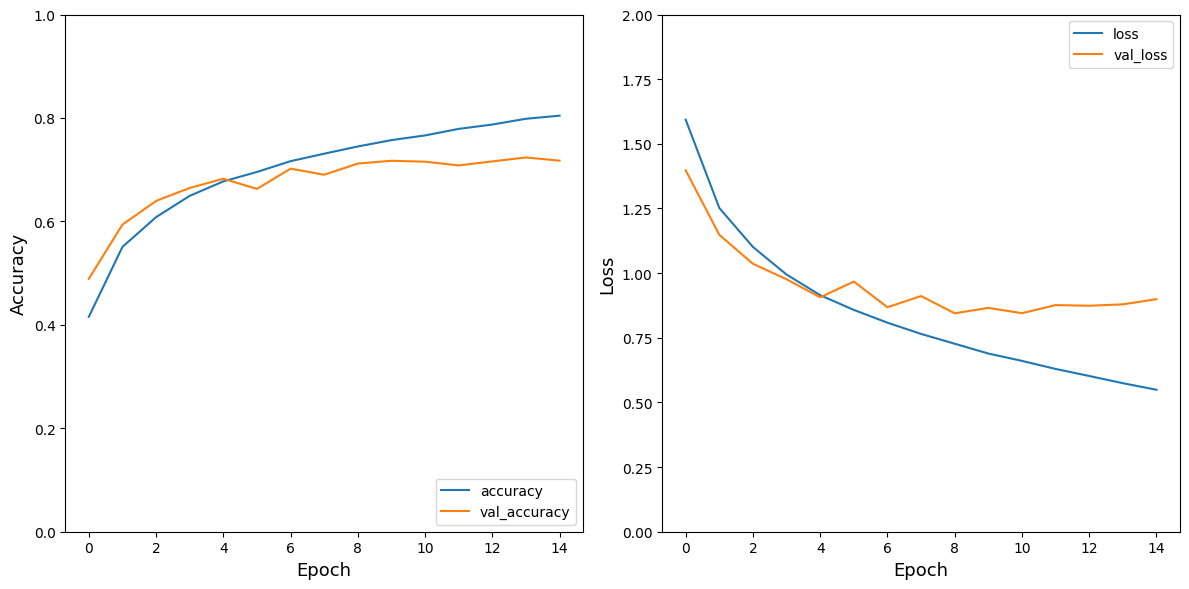

In [12]:
import matplotlib.pyplot as plt

# Degine a subplot grid 1x2
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)

# Plot for accuracy and val_accuracy
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch', fontsize=13)
plt.ylabel('Accuracy', fontsize=13)
plt.ylim([0.0, 1])
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)

# Plot for loss and val_loss
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch', fontsize=13)
plt.ylabel('Loss', fontsize=13)
plt.ylim([0.0, 2])
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [13]:
# Model evaluation on test data
test_loss, test_accuracy = model.evaluate(test_images, test_labels)

print(f'Loss on test set: {test_loss}')
print(f'Accuracy on test set: {test_accuracy}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7106 - loss: 0.8911
Loss on test set: 0.9064510464668274
Accuracy on test set: 0.7071999907493591


### Confusion matrix

- A confusion matrix is a performance measurement tool used in classification tasks, to evaluate the performance of a classification model.
- It is a square matrix where each row represents the instances in a predicted class, and each column represents the instances in an actual class (or vice versa).
- The diagonal elements of the matrix represent the number of correct predictions for each class, while the off-diagonal elements represent incorrect predictions.

By analyzing the confusion matrix, we can gain insights into the model's performance, such as:
- `Accuracy`: The overall accuracy of the model, calculated as the ratio of the sum of correct predictions to the total number of predictions.
- `Precision`: The ratio of true positive predictions to the total number of positive predictions, indicating the model's ability to correctly identify positive cases.
- `Recall`: The ratio of true positive predictions to the total number of actual positive cases, indicating the model's ability to capture all positive cases.
- `F1 Score`: The harmonic mean of precision and recall, providing a balance between the two metrics.

Overall, the confusion matrix provides a comprehensive overview of the model's performance across different classes, enabling us to identify areas for improvement and fine-tuning.

In [14]:
from sklearn.metrics import confusion_matrix

y_pred = model.predict(test_images)
print("First image prediction prob:", y_pred[0])
print("Predictions:", y_pred.argmax(axis=1))

matrix = confusion_matrix(test_labels, y_pred.argmax(axis=1))
print(matrix)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
First image prediction prob: [2.1637559e-03 5.7898257e-02 1.7818355e-03 8.4703887e-01 8.0037662e-06
 5.8284491e-02 2.4843344e-02 8.9122790e-05 2.6699344e-03 5.2223057e-03]
Predictions: [3 8 0 ... 5 4 7]
[[765  23  38  10   9   2   8  10  95  40]
 [ 32 825  10   3   4   3   8   4  39  72]
 [ 98   7 630  34  72  44  55  20  26  14]
 [ 41  11 105 490  57 133  65  35  36  27]
 [ 39   4  81  61 650  36  40  59  21   9]
 [ 19   3  90 143  42 577  27  64  21  14]
 [ 13   3  64  59  28  16 782   8  16  11]
 [ 29   6  55  34  63  64   3 711   7  28]
 [ 68  22  14   7   3   0   6   6 851  23]
 [ 43  93   5   7   3   7   6   6  39 791]]


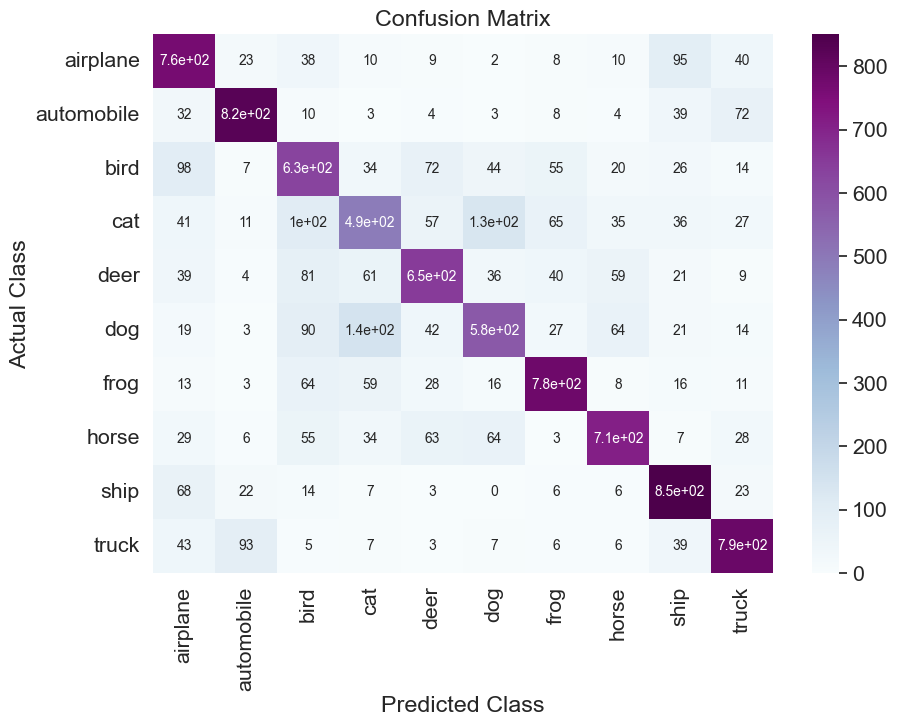

In [15]:
import pandas  as pd
import seaborn as sn    # https://seaborn.pydata.org/

df_cm = pd.DataFrame(matrix, class_names, class_names)
plt.figure(figsize = (10,7))
sn.set_theme(font_scale=1.4) #for label size
sn.heatmap(df_cm, cmap="BuPu",annot=True, annot_kws={"size": 10}) #font size
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix')
plt.show()

### **Visualize the feature maps**
Feature maps are the **representations of features extracted from the input image at each level of the CNN**.

To visualize the latent features computed by a convolutional layer for a given image, you have to extract the output values of that layer.

To do this:
- you need to create a new model with the same input as the original model and the layer you want to analyze as the output layer.
- once you have this new model, you can call it on the image you want to visualize, and it will output the feature maps for that specific layer.

This can help you understand what features the model is detecting in the image and how it is processing the input data.

To access the layers, you can use  `model.layers`

In [16]:
# Print the name and shape of the conv layers
print(type(model.layers))
print(model.layers[0])

for i in range(len(model.layers)):
	layer = model.layers[i]
	if "conv" in layer.name:
		print(i, layer.name, layer.output.shape)


<class 'list'>
<Conv2D name=conv2d, built=True>
0 conv2d (None, 30, 30, 32)
2 conv2d_1 (None, 13, 13, 64)
4 conv2d_2 (None, 4, 4, 64)


1. Show the feature maps extracted by the first conv layer
2. Build a new model to output right after the first hidden layer

In [17]:
from tensorflow import keras

def visualize_features_map(im: np.ndarray, layer_index: int):

    # NOTE: You can get the model by its name, but consider that the names assigned change if you re-run the code. It's better to select the layer using the list index
    model_v = keras.Model(inputs = model.inputs[0], outputs = model.layers[layer_index].output)
    model_v.summary()

    # Get the feature maps
    feature_maps = model_v.predict(np.array([im]), verbose=False)[0]

    # Print the shape of feature_maps
    print("Feature maps shape:", feature_maps.shape)

    # Predict class name
    p = model.predict(np.array([im]), verbose=False)
    print("Image class name:", class_names[np.argmax(p)])
    
    # Show the image for which we want to compute the feature maps and its class
    plt.imshow(im)
    plt.show()

    # Show the feature map corresponding to a given filter as an image
    fmap=feature_maps[:,:,5]

    plt.imshow(fmap, cmap="gray")
    plt.show()
    
    # Show all the feature maps
    fig  = plt.figure(figsize=(10, 10))
    for i in range(feature_maps.shape[2]):
        sub = fig.add_subplot(8, 8, i+1)
        plt.xticks([])
        plt.yticks([])
        sub.imshow(feature_maps[:,:,i], cmap = "gray")

- Run the function to show the feature maps extracted by the first conv layer

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896 (3.50 KB)

 Trainable params: 896 (3.50 KB)

 Non-trainable params: 0 (0.00 B)

Feature maps shape: (30, 30, 32)
Image class name: truck


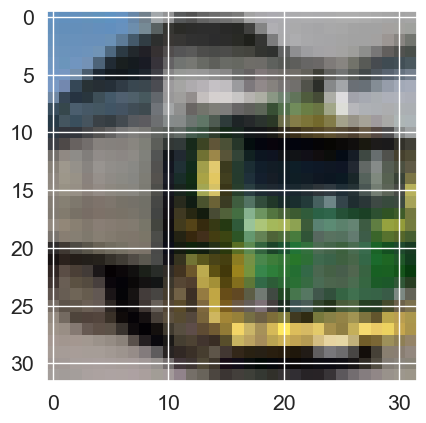

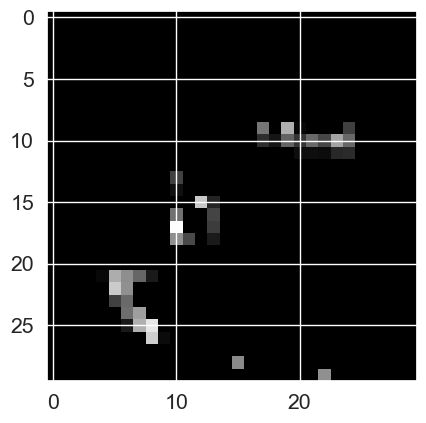

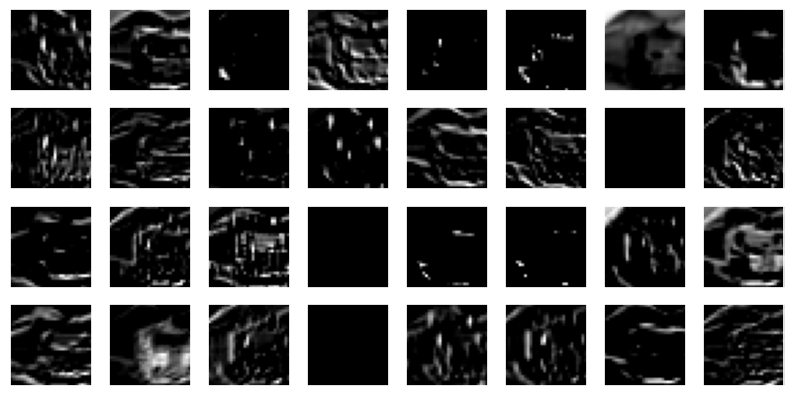

In [18]:
visualize_features_map(train_images[14], 0)

- Repeat the above process to show the feature maps extracted by the second conv layer


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,392 (75.75 KB)

 Trainable params: 19,392 (75.75 KB)

 Non-trainable params: 0 (0.00 B)

Feature maps shape: (13, 13, 64)
Image class name: truck


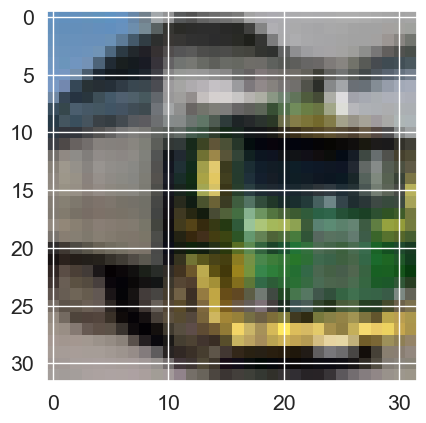

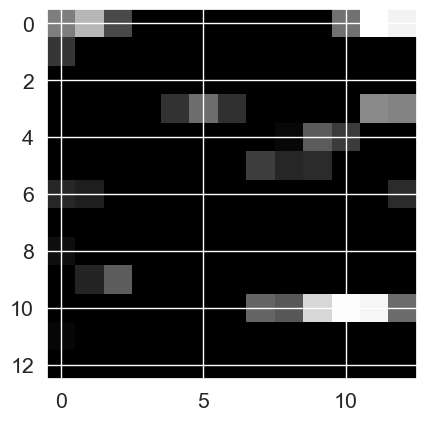

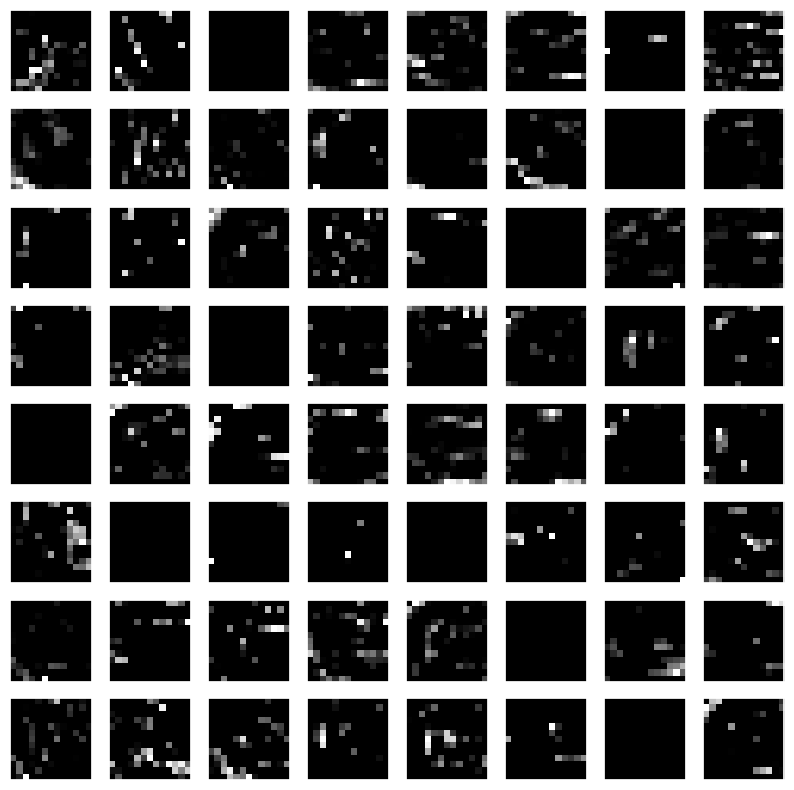

In [19]:
visualize_features_map(train_images[14], 2)

- Repeat the above process to show the feature maps extracted by the third conv layer


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,392 (75.75 KB)

 Trainable params: 19,392 (75.75 KB)

 Non-trainable params: 0 (0.00 B)

Feature maps shape: (6, 6, 64)
Image class name: truck


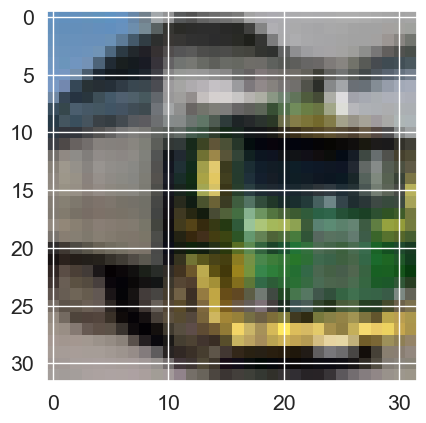

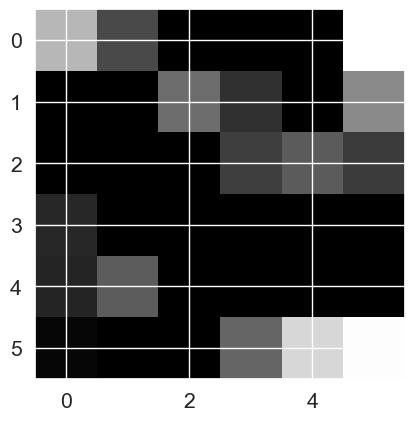

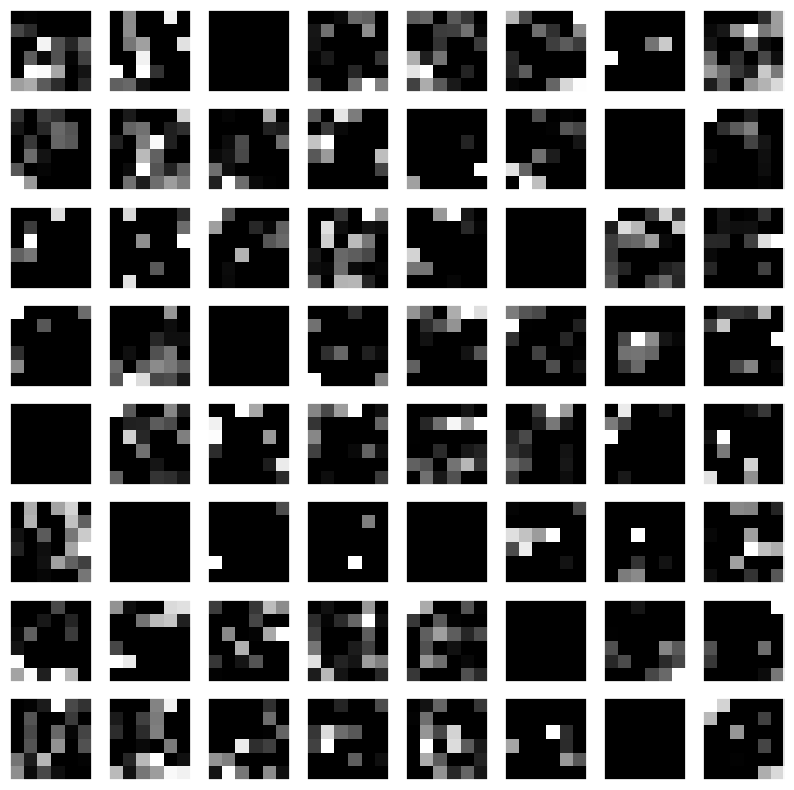

In [20]:
visualize_features_map(train_images[14], 3)

### Plot the learned Filters

Weights range: (-0.4898146390914917, 0.41105395555496216)
Normalized weights range: (0.0, 1.0)


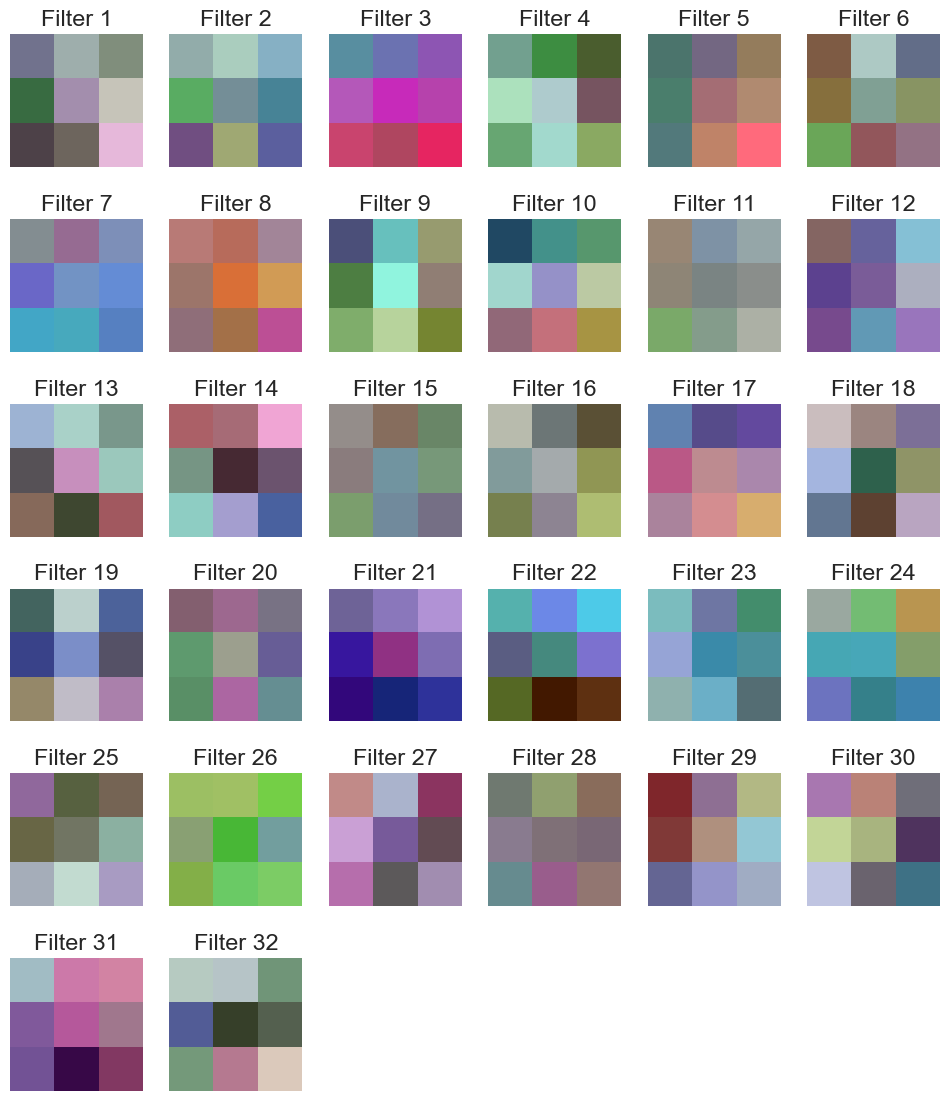

In [21]:
# Extracting the weights of the first convolutional layer
conv_weights = model.layers[0].get_weights()[0]
print("Weights range:", (float(np.min(conv_weights)), float(np.max(conv_weights))))

# Normalizing the weights to [0, 1]
conv_weights_normalized = (conv_weights - np.min(conv_weights)) / (np.max(conv_weights) - np.min(conv_weights))
print("Normalized weights range:", (float(np.min(conv_weights_normalized)), float(np.max(conv_weights_normalized))))

# Plotting the learned filters
plt.figure(figsize=(12, 14))
for i in range(conv_weights.shape[-1]):
    plt.subplot(6, 6, i + 1)
    plt.imshow(conv_weights_normalized[:, :, :, i].squeeze(), cmap='gray')
    plt.axis('off')
    plt.title(f'Filter {i+1}')
plt.show()

**Load and save the model doc ->** [link](https://keras.io/api/models/model_saving_apis/model_saving_and_loading/)

In [22]:
# save model
model.save('model_cnn.keras')